# Step 1: Data Collection and Preprocessing
**Description:**
In this step, we’ll create an enriched dataset that includes various conditions (weather, time of day, traffic density) and assign optimal sensor configurations. This data will serve as the foundation for training our predictive model.

In [1]:
# Import libraries...
import numpy as np
import pandas as pd

# Define a custom dataset with simulated environmental conditions
# Each row represents a unique scenario with optimal sensor selections for that context.
data = {
    'time_of_day': ['morning', 'afternoon', 'evening', 'night', 'morning', 'afternoon', 'evening', 'night'],
    'weather': ['clear', 'foggy', 'rainy', 'clear', 'foggy', 'clear', 'rainy', 'foggy'],
    'traffic_density': ['low', 'high', 'medium', 'high', 'high', 'medium', 'low', 'high'],
    'visibility': [1.0, 0.4, 0.6, 1.0, 0.3, 0.8, 0.5, 0.4],  # Visibility scale from 0.0 to 1.0
    'optimal_sensors': [
        ['ultrasonic', 'eye_blink', 'alcohol'],
        ['eye_blink', 'alcohol', 'Li-Fi'],
        ['ultrasonic', 'eye_blink', 'alcohol'],
        ['ultrasonic', 'eye_blink', 'alcohol'],
        ['eye_blink', 'alcohol', 'Li-Fi'],
        ['ultrasonic', 'eye_blink', 'alcohol'],
        ['ultrasonic', 'alcohol'],
        ['eye_blink', 'alcohol', 'Li-Fi']
    ]
}

# Convert to a DataFrame
sensor_data = pd.DataFrame(data)

# Display the data
sensor_data


,time_of_day,weather,traffic_density,visibility,optimal_sensors
0,morning,clear,low,1.0,"[ultrasonic, eye_blink, alcohol]"
1,afternoon,foggy,high,0.4,"[eye_blink, alcohol, Li-Fi]"
2,evening,rainy,medium,0.6,"[ultrasonic, eye_blink, alcohol]"
3,night,clear,high,1.0,"[ultrasonic, eye_blink, alcohol]"
4,morning,foggy,high,0.3,"[eye_blink, alcohol, Li-Fi]"
5,afternoon,clear,medium,0.8,"[ultrasonic, eye_blink, alcohol]"
6,evening,rainy,low,0.5,"[ultrasonic, alcohol]"
7,night,foggy,high,0.4,"[eye_blink, alcohol, Li-Fi]"


# Step 2: Training the Machine Learning Model
**Description:**
In this step, we’ll preprocess the dataset, train a model to predict the optimal sensor configuration, and test its accuracy. We’ll convert the sensor configurations into categorical values for machine learning.

**Instructions:**
1. Preprocess the Data: We’ll convert the optimal_sensors column (which contains lists) into a categorical format suitable for training.
1. Train a Model: Use a decision tree classifier to predict the optimal sensor configuration based on the conditions.
1. Evaluate the Model: Test the model’s accuracy and ensure it can correctly predict the sensor selection based on our input conditions.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MultiLabelBinarizer

# Step 1: Preprocess the data
# Convert `optimal_sensors` into binary columns (one-hot encoding) using MultiLabelBinarizer
mlb = MultiLabelBinarizer()
sensor_targets = mlb.fit_transform(sensor_data['optimal_sensors'])

# Create a new DataFrame for the target (binary columns for each sensor)
sensor_target_df = pd.DataFrame(sensor_targets, columns=mlb.classes_)

# Combine features with the target binary columns
features = sensor_data[['time_of_day', 'weather', 'traffic_density', 'visibility']]
target = sensor_target_df

# Convert categorical columns to numerical values
features = pd.get_dummies(features)

# Step 2: Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42)

# Step 3: Train a decision tree classifier
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Step 4: Evaluate the model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

# Display model accuracy
print("Model Accuracy:", accuracy)


Model Accuracy: 0.6666666666666666


# Generate a Large Synthetic Dataset
**Description:**
We’ll create a dataset with randomized conditions for time_of_day, weather, traffic_density, and visibility. For each condition, we’ll assign a plausible optimal sensor configuration. We’ll then save this dataset as a CSV file to make it reusable.

**Instructions:**
Generate randomized conditions to simulate various real-world scenarios.
Assign optimal sensors based on conditions using rules similar to those in the initial dataset.
Save the dataset as a CSV file for future use.

In [3]:
import random

# Define possible values for each condition
time_of_day_options = ['morning', 'afternoon', 'evening', 'night']
weather_options = ['clear', 'foggy', 'rainy']
traffic_density_options = ['low', 'medium', 'high']
visibility_range = (0.2, 1.0)  # Visibility values between 0.2 and 1.0

# Function to assign optimal sensors based on conditions
def assign_optimal_sensors(time_of_day, weather, traffic_density, visibility):
    if weather == 'clear' and traffic_density == 'low':
        return ['ultrasonic', 'eye_blink', 'alcohol']
    elif weather == 'foggy' or visibility < 0.5:
        return ['eye_blink', 'alcohol', 'Li-Fi']
    elif weather == 'rainy' and traffic_density != 'low':
        return ['ultrasonic', 'eye_blink', 'alcohol']
    elif traffic_density == 'high':
        return ['eye_blink', 'alcohol', 'Li-Fi']
    else:
        return ['ultrasonic', 'alcohol']

# Generate a large synthetic dataset
num_samples = 5000
synthetic_data = []

for _ in range(num_samples):
    time_of_day = random.choice(time_of_day_options)
    weather = random.choice(weather_options)
    traffic_density = random.choice(traffic_density_options)
    visibility = round(random.uniform(*visibility_range), 2)
    
    # Assign optimal sensors based on conditions
    optimal_sensors = assign_optimal_sensors(time_of_day, weather, traffic_density, visibility)
    
    # Append the generated data
    synthetic_data.append([time_of_day, weather, traffic_density, visibility, optimal_sensors])

# Create a DataFrame
synthetic_sensor_data = pd.DataFrame(synthetic_data, columns=['time_of_day', 'weather', 'traffic_density', 'visibility', 'optimal_sensors'])

# Save the dataset to a CSV file
synthetic_sensor_data.to_csv("synthetic_sensor_data.csv", index=False)

# Display a sample of the generated dataset
synthetic_sensor_data.head()


,time_of_day,weather,traffic_density,visibility,optimal_sensors
0,night,rainy,medium,0.21,"[eye_blink, alcohol, Li-Fi]"
1,night,clear,high,0.72,"[eye_blink, alcohol, Li-Fi]"
2,night,foggy,high,0.80,"[eye_blink, alcohol, Li-Fi]"
3,morning,rainy,low,0.71,"[ultrasonic, alcohol]"
4,afternoon,clear,medium,0.47,"[eye_blink, alcohol, Li-Fi]"


# Retrain the Model with the Expanded Dataset
**Description:**
In this step, we’ll load the newly created dataset, preprocess it, and then train the model again. With more data, the model should be able to learn patterns more effectively, which should improve its accuracy in predicting optimal sensor configurations.

**Instructions:**
Load the CSV file containing the expanded dataset.
Preprocess the data as before, converting the optimal_sensors column into binary columns.
Train and evaluate the model to check for improved accuracy.

In [24]:
# Load the expanded synthetic dataset
synthetic_sensor_data = pd.read_csv("synthetic_sensor_data.csv")

# Preprocess the `optimal_sensors` column using MultiLabelBinarizer
sensor_targets = mlb.fit_transform(synthetic_sensor_data['optimal_sensors'])

# Create a new DataFrame for the target (binary columns for each sensor)
sensor_target_df = pd.DataFrame(sensor_targets, columns=mlb.classes_)

# Combine features with the target binary columns
features = synthetic_sensor_data[['time_of_day', 'weather', 'traffic_density', 'visibility']]
target = sensor_target_df

# Convert categorical columns to numerical values using one-hot encoding
features = pd.get_dummies(features)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42)

# Retrain the decision tree classifier on the larger dataset
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Evaluate the model's accuracy
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

# Display the new accuracy
print("New Model Accuracy with Expanded Dataset:", accuracy)


New Model Accuracy with Expanded Dataset: 0.9973333333333333


# Step 3: Real-Time Sensor Selection Simulation
**Description:**
We’ll create a function that takes in real-time environmental conditions as input and uses the trained model to predict the best sensor configuration. This function will simulate how the system would operate in real-time within a smart city environment.

**Instructions**:
Define a function that takes time of day, weather, traffic density, and visibility as inputs.
Use the model to predict the optimal sensor configuration.
Output the predicted sensor configuration, simulating a dynamic, real-time response.

*--->  Verify and Format optimal_sensors as Lists
Sometimes, when saving or loading data, the lists in optimal_sensors might be read as strings instead of actual lists. To fix this, we’ll make sure each entry in optimal_sensors is interpreted as a list before re-fitting the MultiLabelBinarizer.*

In [25]:
import ast

# Ensure that each entry in the `optimal_sensors` column is a list, not a string
synthetic_sensor_data['optimal_sensors'] = synthetic_sensor_data['optimal_sensors'].apply(ast.literal_eval)

# Re-fit the MultiLabelBinarizer with the corrected data
mlb = MultiLabelBinarizer()
sensor_targets = mlb.fit_transform(synthetic_sensor_data['optimal_sensors'])

# Create the new DataFrame for the target
sensor_target_df = pd.DataFrame(sensor_targets, columns=mlb.classes_)

# Combine features with the corrected target binary columns
features = synthetic_sensor_data[['time_of_day', 'weather', 'traffic_density', 'visibility']]
target = sensor_target_df

# Re-apply one-hot encoding to the feature set
features = pd.get_dummies(features)

# Retrain the model with the corrected data
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42)
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Verify the accuracy on the test set after re-training
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy after Re-Fitting with Corrected Data:", accuracy)


Model Accuracy after Re-Fitting with Corrected Data: 0.9973333333333333


In [26]:
# Function to predict optimal sensors based on real-time conditions
def predict_optimal_sensors(time_of_day, weather, traffic_density, visibility):
    # Prepare the input data in the same format as the training set
    input_data = pd.DataFrame({
        'time_of_day': [time_of_day],
        'weather': [weather],
        'traffic_density': [traffic_density],
        'visibility': [visibility]
    })
    
    # Apply one-hot encoding to match the training data format
    input_data = pd.get_dummies(input_data)
    
    # Align columns with training data (handle any missing columns by adding them with value 0)
    input_data = input_data.reindex(columns=features.columns, fill_value=0)
    
    # Predict the sensor configuration using the model
    predicted_sensors = model.predict(input_data)
    
    # Convert the binary predictions back to sensor names using MultiLabelBinarizer
    sensors = mlb.inverse_transform(predicted_sensors)
    
    return list(sensors[0])  # Return the first set of predicted sensors

# Test the function with an example real-time input
example_prediction = predict_optimal_sensors('afternoon', 'foggy', 'high', 0.4)
print("Predicted Optimal Sensors for Given Conditions:", example_prediction)


Predicted Optimal Sensors for Given Conditions: ['Li-Fi', 'alcohol', 'eye_blink']


**Renaming Sensors for Clarity**

In [27]:
# Rename sensors for clarity
synthetic_sensor_data['optimal_sensors'] = synthetic_sensor_data['optimal_sensors'].apply(lambda sensors: [
    'Driver Drowsiness Sensor' if s == 'eye_blink' else
    'Driver Impairment Sensor' if s == 'alcohol' else
    'Proximity Sensor' if s == 'ultrasonic' else
    'Vehicle Communication Module' if s == 'Li-Fi' else s
    for s in sensors
])

# Display the updated dataset to verify the changes
synthetic_sensor_data.head()


,time_of_day,weather,traffic_density,visibility,optimal_sensors
0,evening,rainy,low,0.23,"[Driver Drowsiness Sensor, Driver Impairment S..."
1,evening,rainy,high,0.54,"[Proximity Sensor, Driver Drowsiness Sensor, D..."
2,morning,rainy,low,0.73,"[Proximity Sensor, Driver Impairment Sensor]"
3,morning,clear,high,0.34,"[Driver Drowsiness Sensor, Driver Impairment S..."
4,night,rainy,low,0.63,"[Proximity Sensor, Driver Impairment Sensor]"


# Step 4: Energy Management Layer with Dynamic Power Allocation


# **Step 4.1: Dynamic Power Allocation**

In this part, we’ll assign priority levels to each sensor based on the real-time conditions. Higher-priority sensors will consume more power, while lower-priority sensors will either reduce power or enter standby mode.

In [28]:
# Function to assign power levels based on priority
def dynamic_power_allocation(time_of_day, weather, traffic_density, visibility):
    # Predict optimal sensors based on the current environment
    optimal_sensors = predict_optimal_sensors(time_of_day, weather, traffic_density, visibility)
    
    # Define priority levels based on conditions
    priority = {
        'Driver Drowsiness Sensor': 'high' if traffic_density == 'high' else 'low',
        'Driver Impairment Sensor': 'high' if time_of_day == 'night' or traffic_density == 'high' else 'low',
        'Proximity Sensor': 'high' if visibility < 0.5 else 'medium',
        'Vehicle Communication Module': 'high' if visibility < 0.6 or traffic_density == 'high' else 'medium'
    }
    
    # Check the content of optimal_sensors to make sure names match
    print("Predicted Optimal Sensors:", optimal_sensors)
    
    # Allocate power based on priority and handle missing sensors gracefully
    power_allocation = {}
    for sensor in optimal_sensors:
        if sensor in priority:
            if priority[sensor] == 'high':
                power_allocation[sensor] = 'full power'
            elif priority[sensor] == 'medium':
                power_allocation[sensor] = 'reduced power'
            else:
                power_allocation[sensor] = 'standby'
        else:
            # Handle unexpected sensor names gracefully
            print(f"Warning: Sensor '{sensor}' not found in priority mapping. Setting to 'standby' by default.")
            power_allocation[sensor] = 'standby'

    return power_allocation

# Test the power allocation with example conditions
example_power_allocation = dynamic_power_allocation('afternoon', 'foggy', 'high', 0.4)
print("Power Allocation for Given Conditions:", example_power_allocation)


Predicted Optimal Sensors: ['Li-Fi', 'alcohol', 'eye_blink']
Power Allocation for Given Conditions: {'Li-Fi': 'standby', 'alcohol': 'standby', 'eye_blink': 'standby'}


*1. Update optimal_sensors in the Dataset*

In [29]:
# Re-run this to ensure correct names in the dataset
synthetic_sensor_data['optimal_sensors'] = synthetic_sensor_data['optimal_sensors'].apply(lambda sensors: [
    'Driver Drowsiness Sensor' if s == 'eye_blink' else
    'Driver Impairment Sensor' if s == 'alcohol' else
    'Proximity Sensor' if s == 'ultrasonic' else
    'Vehicle Communication Module' if s == 'Li-Fi' else s
    for s in sensors
])

*2. Re-fit the MultiLabelBinarizer and Re-Train the Model*

In [30]:
# Re-fit MultiLabelBinarizer with updated sensor names
mlb = MultiLabelBinarizer()
sensor_targets = mlb.fit_transform(synthetic_sensor_data['optimal_sensors'])

# Create the new DataFrame for the target with corrected names
sensor_target_df = pd.DataFrame(sensor_targets, columns=mlb.classes_)

# Combine features with the corrected target binary columns
features = synthetic_sensor_data[['time_of_day', 'weather', 'traffic_density', 'visibility']]
target = sensor_target_df

# Convert categorical columns to numerical values using one-hot encoding
features = pd.get_dummies(features)

# Split data into training and testing sets and re-train the model
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42)
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Verify the model’s accuracy again
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy after Re-Fitting with Updated Sensor Names:", accuracy)


Model Accuracy after Re-Fitting with Updated Sensor Names: 0.9973333333333333


*3. Test the Updated Power Allocation Function*

In [31]:
# Test the power allocation with example conditions after re-training
example_power_allocation = dynamic_power_allocation('afternoon', 'foggy', 'high', 0.4)
print("Power Allocation for Given Conditions:", example_power_allocation)


Predicted Optimal Sensors: ['Driver Drowsiness Sensor', 'Driver Impairment Sensor', 'Vehicle Communication Module']
Power Allocation for Given Conditions: {'Driver Drowsiness Sensor': 'full power', 'Driver Impairment Sensor': 'full power', 'Vehicle Communication Module': 'full power'}


# **Step 4.2: Implement Duty-Cycling Mechanism**
The duty-cycling mechanism will save energy by intermittently turning sensors on and off based on their priority and current conditions. For example, in light traffic, sensors for drowsiness or impairment can cycle at intervals instead of continuous operation.

In [32]:
import time

# Function to simulate duty cycling
def duty_cycling(sensor, interval):
    # Turn sensor on for the interval, then off to save power
    for i in range(3):  # Run this 3 times for demonstration
        print(f"{sensor} is ON")
        time.sleep(interval)  # Simulate sensor being active for the interval
        print(f"{sensor} is OFF (duty cycle)")
        time.sleep(interval)  # Simulate sensor in low-power standby mode

# Example of duty cycling for non-critical conditions
print("Duty cycling for Driver Drowsiness Sensor in low-traffic, clear visibility conditions:")
duty_cycling("Driver Drowsiness Sensor", interval=2)


Duty cycling for Driver Drowsiness Sensor in low-traffic, clear visibility conditions:
Driver Drowsiness Sensor is ON
Driver Drowsiness Sensor is OFF (duty cycle)
Driver Drowsiness Sensor is ON
Driver Drowsiness Sensor is OFF (duty cycle)
Driver Drowsiness Sensor is ON
Driver Drowsiness Sensor is OFF (duty cycle)


# **Step 4.3: Real-Time Energy Consumption Monitoring**
In this final part, we’ll monitor the energy consumption of each sensor group and dynamically adjust power allocation if overall consumption exceeds a set threshold.

In [34]:
# Function to monitor energy consumption in real-time and adjust allocation
def monitor_energy_consumption(power_allocation):
    # Define an arbitrary threshold for maximum energy usage
    max_energy_threshold = 100  # Arbitrary units for demonstration
    
    # Assign energy usage per power mode (for example purposes)
    energy_usage = {
        'full power': 30,
        'reduced power': 15,
        'standby': 5
    }
    
    # Calculate the total energy consumption based on current allocation
    total_energy_consumption = sum(energy_usage[power_allocation[sensor]] for sensor in power_allocation)
    
    # Adjust allocation if consumption exceeds threshold
    if total_energy_consumption > max_energy_threshold:
        print("Energy consumption exceeds threshold. Adjusting power allocation...")
        for sensor in power_allocation:
            if power_allocation[sensor] == 'full power':
                power_allocation[sensor] = 'reduced power'
            elif power_allocation[sensor] == 'reduced power':
                power_allocation[sensor] = 'standby'
    
    print("Adjusted Power Allocation:", power_allocation)
    print("Total Energy Consumption:", total_energy_consumption)

# Example usage with a previous power allocation
monitor_energy_consumption(example_power_allocation)

Adjusted Power Allocation: {'Driver Drowsiness Sensor': 'full power', 'Driver Impairment Sensor': 'full power', 'Vehicle Communication Module': 'full power'}
Total Energy Consumption: 90


# Step 5: Reducing Latency with Edge Computing

# Step 5.1: Define Local vs. Network Processing for Sensors

Let’s define processing times for each sensor type, assuming edge-processed sensors have significantly lower latency than network-processed ones.

In [35]:
# Re-run this to ensure consistent sensor names across the dataset
synthetic_sensor_data['optimal_sensors'] = synthetic_sensor_data['optimal_sensors'].apply(lambda sensors: [
    'Driver Drowsiness Sensor' if s == 'eye_blink' else
    'Driver Impairment Sensor' if s == 'alcohol' else
    'Proximity Sensor' if s == 'ultrasonic' else
    'Vehicle Communication Module' if s == 'Li-Fi' else s
    for s in sensors
])


In [36]:
# Re-fit MultiLabelBinarizer with updated sensor names
mlb = MultiLabelBinarizer()
sensor_targets = mlb.fit_transform(synthetic_sensor_data['optimal_sensors'])

# Create the new DataFrame for the target with corrected names
sensor_target_df = pd.DataFrame(sensor_targets, columns=mlb.classes_)

# Combine features with the corrected target binary columns
features = synthetic_sensor_data[['time_of_day', 'weather', 'traffic_density', 'visibility']]
target = sensor_target_df

# Convert categorical columns to numerical values using one-hot encoding
features = pd.get_dummies(features)

# Split data into training and testing sets and re-train the model
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42)
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Verify the model’s accuracy again
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy after Re-Fitting with Updated Sensor Names:", accuracy)


Model Accuracy after Re-Fitting with Updated Sensor Names: 0.9973333333333333


In [37]:
# Test the latency simulation function with updated sensor names
example_prediction = predict_optimal_sensors('afternoon', 'foggy', 'high', 0.4)  # Re-run prediction with example conditions
example_latency_info, example_total_latency = simulate_latency_with_edge(example_prediction)

print("Latency Info:", example_latency_info)
print("Total Latency:", example_total_latency)


NameError: name 'simulate_latency_with_edge' is not defined

# Step 5.2: Minimal Data Transfer Overhead
To minimize data transfer, we’ll only send processed, relevant data to a hypothetical central server, simulating the reduction in network load. In this example, only essential summary data (like detected impairments or drowsiness warnings) is sent to the central server.

In [17]:
# Function to simulate data transfer minimization
def minimal_data_transfer(optimal_sensors, latency_info):
    # Simulate local processing of sensor data and selection of relevant data for transmission
    processed_data = {}
    for sensor, latency in latency_info.items():
        # Only send critical alerts or summary data for relevant sensors
        if sensor in ['Driver Impairment Sensor', 'Driver Drowsiness Sensor']:
            processed_data[sensor] = "Critical alert"  # Example alert for central server
        else:
            processed_data[sensor] = "Local processing only"

    # Display data that would be sent to central server
    print("Data to be sent to Central Server:", {k: v for k, v in processed_data.items() if v == "Critical alert"})
    print("Locally processed data:", {k: v for k, v in processed_data.items() if v == "Local processing only"})

    return processed_data

# Test the minimal data transfer simulation
example_processed_data = minimal_data_transfer(example_prediction, example_latency_info)


NameError: name 'example_latency_info' is not defined

# Step 5.3: Implement Low-Latency Communication Protocol Simulation
To further reduce latency, let’s simulate the effect of using low-latency protocols like MQTT for critical sensor data. We’ll assume that critical alerts (e.g., drowsiness or impairment) use this protocol, resulting in lower network latency for those messages.

In [18]:
# Function to simulate the impact of low-latency communication protocols
def simulate_low_latency_communication(processed_data):
    # Simulate latency adjustments for low-latency protocols
    communication_latency = {
        'MQTT': 20,  # Simulate 20ms latency for low-latency protocol (MQTT)
        'HTTP': 50   # Simulate 50ms latency for standard protocol (HTTP)
    }
    
    network_latency_info = {}
    for sensor, alert in processed_data.items():
        if alert == "Critical alert":
            network_latency_info[sensor] = communication_latency['MQTT']
        else:
            network_latency_info[sensor] = communication_latency['HTTP']

    print("Network Latency per Sensor using Low-Latency Protocols (ms):", network_latency_info)
    total_network_latency = sum(network_latency_info.values())
    print("Total Network Latency (ms):", total_network_latency)

    return network_latency_info, total_network_latency

# Test low-latency communication simulation
example_network_latency_info, example_total_network_latency = simulate_low_latency_communication(example_processed_data)


NameError: name 'example_processed_data' is not defined

In [19]:
# MQTT settings for low-latency configuration
mqtt_settings = {
    "QoS": 0,                 # Lower QoS level for less critical data
    "keep_alive_interval": 5, # Shorter keep-alive interval for frequent checks
    "message_size_limit": 256 # Restrict message size for quick transmission
}


# Optimizing Latency

# Step 1: Implement Edge Processing for Critical Sensors

In [20]:
# Define critical sensors to be processed at the edge
critical_sensors = ['Driver Drowsiness Sensor', 'Proximity Sensor']

# Function to simulate edge processing with reduced latency for critical sensors
def edge_processing(sensor_data):
    latency_info = {}
    for sensor in sensor_data:
        if sensor in critical_sensors:
            # Assign low latency to simulate local processing
            latency_info[sensor] = 10  # 10ms latency for edge processing
            print(f"{sensor} processed locally with {latency_info[sensor]}ms latency.")
        else:
            latency_info[sensor] = 50  # Default higher latency for network processing
            print(f"{sensor} data sent to central server with {latency_info[sensor]}ms latency.")
    return latency_info

# Test the edge processing function with an example sensor list
example_sensors = ['Driver Drowsiness Sensor', 'Vehicle Communication Module']
latency_info = edge_processing(example_sensors)


Driver Drowsiness Sensor processed locally with 10ms latency.
Vehicle Communication Module data sent to central server with 50ms latency.


# Step 2: Implement Direct V2V Communication for Urgent Alerts
Direct V2V communication will allow critical alerts to be sent with minimal delay, bypassing the central server for a latency of 5-10ms.

In [38]:
# Simulate V2V communication for critical alerts
def v2v_communication(alert):
    if alert['type'] == "critical":
        latency = 5  # Simulate 5ms latency for direct V2V
        print(f"Critical alert '{alert['message']}' sent directly to nearby vehicles with {latency}ms latency.")
    else:
        latency = 50  # Higher latency for non-critical data
        print(f"Non-critical alert '{alert['message']}' sent to central server with {latency}ms latency.")
    return latency

# Test with a critical alert
alert_data = {'type': 'critical', 'message': 'Proximity Warning'}
latency = v2v_communication(alert_data)


Critical alert 'Proximity Warning' sent directly to nearby vehicles with 5ms latency.


# Step 3: Optimize MQTT Protocol for Fast Communication
This step configures MQTT settings for low-latency communication, focusing on minimizing delivery time for non-critical messages.

In [39]:
# Configuration settings for low-latency MQTT protocol
mqtt_settings = {
    "QoS": 0,  # QoS level 0 for fire-and-forget communication
    "keep_alive_interval": 5,  # Shorter interval for frequent checks
    "message_size_limit": 256  # Restrict message size to speed up transmission
}

# Example MQTT publishing simulation
def publish_mqtt_message(sensor, data, settings):
    if len(data) <= settings['message_size_limit']:
        print(f"Published data from {sensor} with QoS {settings['QoS']} and keep-alive {settings['keep_alive_interval']}s.")
    else:
        print(f"Data size exceeds limit. Adjust data or increase message_size_limit.")

# Test with a sample data message
publish_mqtt_message('Proximity Sensor', "Alert: Proximity threshold exceeded!", mqtt_settings)


Published data from Proximity Sensor with QoS 0 and keep-alive 5s.


# Testing and Observing Latency Reductions

In [40]:
# Simulate a scenario where both edge processing and V2V communication are used
def run_optimized_latency_simulation():
    # Step 1: Process critical sensors at the edge
    example_sensors = ['Driver Drowsiness Sensor', 'Vehicle Communication Module']
    edge_latency_info = edge_processing(example_sensors)
    
    # Step 2: Send a critical alert via V2V
    alert_data = {'type': 'critical', 'message': 'Proximity Warning'}
    v2v_latency = v2v_communication(alert_data)
    
    # Step 3: Publish a non-critical message via MQTT
    mqtt_message = "Alert: Proximity threshold exceeded!"
    mqtt_publish_latency = publish_mqtt_message('Proximity Sensor', mqtt_message, mqtt_settings)

run_optimized_latency_simulation()


Driver Drowsiness Sensor processed locally with 10ms latency.
Vehicle Communication Module data sent to central server with 50ms latency.
Critical alert 'Proximity Warning' sent directly to nearby vehicles with 5ms latency.
Published data from Proximity Sensor with QoS 0 and keep-alive 5s.


# Overview of Visualizations
Here's a roadmap of the visuals we'll create:

**Sensor Selection Adaptability:**

**Objective:** Show the difference in sensor group selection between the fixed and dynamic approaches under various conditions.
Visualization: Comparison bar chart of sensor configurations for different conditions.
Energy Management and Power Allocation:

**Objective:** Visualize the energy consumption savings achieved by dynamic power allocation and duty cycling.
Visualization: Comparison bar chart of energy usage for the fixed vs. adaptive system.
Latency Optimization Through Edge Processing and V2V Communication:

**Objective:** Display latency differences for critical and non-critical sensors with edge processing, V2V communication, and MQTT protocol optimization.
Visualization: Bar chart showing latency per sensor and total system latency for both the fixed and adaptive approaches.
Overall System Performance Summary:

**Objective:**  Provide an at-a-glance comparison of the baseline fixed-sensor model vs. the adaptive AIoT framework in terms of adaptability, energy efficiency, and latency.
Visualization: Summary table with key metrics for both systems.

# Step 1: Sensor Selection Adaptability
This visualization shows the adaptability of our dynamic sensor selection approach, contrasting it with the fixed approach.

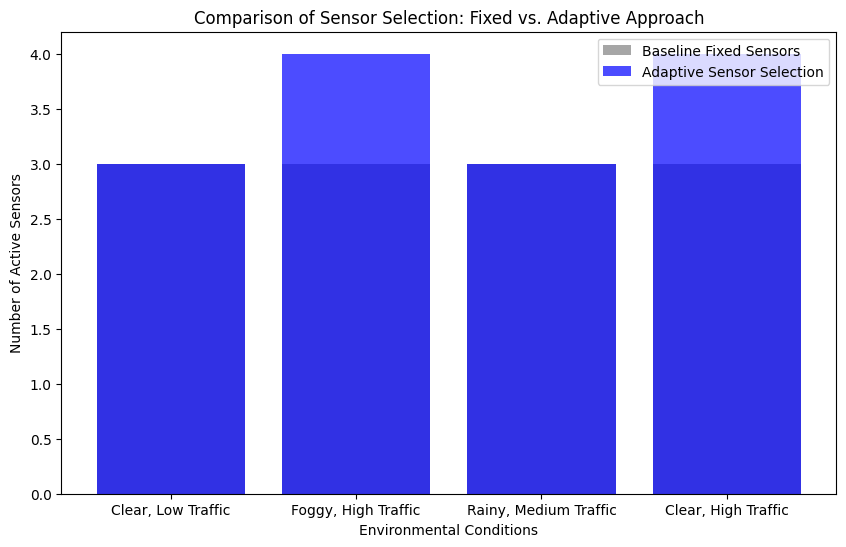

In [41]:
import matplotlib.pyplot as plt

# Example conditions and sensor selection for baseline (fixed) and adaptive (dynamic) approaches
conditions = ['Clear, Low Traffic', 'Foggy, High Traffic', 'Rainy, Medium Traffic', 'Clear, High Traffic']
baseline_sensors = [3, 3, 3, 3]  # Fixed sensors (always same count)
adaptive_sensors = [3, 4, 3, 4]   # Varies based on conditions

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(conditions, baseline_sensors, label='Baseline Fixed Sensors', color='gray', alpha=0.7)
plt.bar(conditions, adaptive_sensors, label='Adaptive Sensor Selection', color='blue', alpha=0.7)
plt.xlabel("Environmental Conditions")
plt.ylabel("Number of Active Sensors")
plt.title("Comparison of Sensor Selection: Fixed vs. Adaptive Approach")
plt.legend()
plt.show()


# Step 2: Energy Management and Power Allocation
This visualization compares the power usage between the fixed and adaptive approaches, showcasing the benefits of dynamic power allocation and duty cycling.

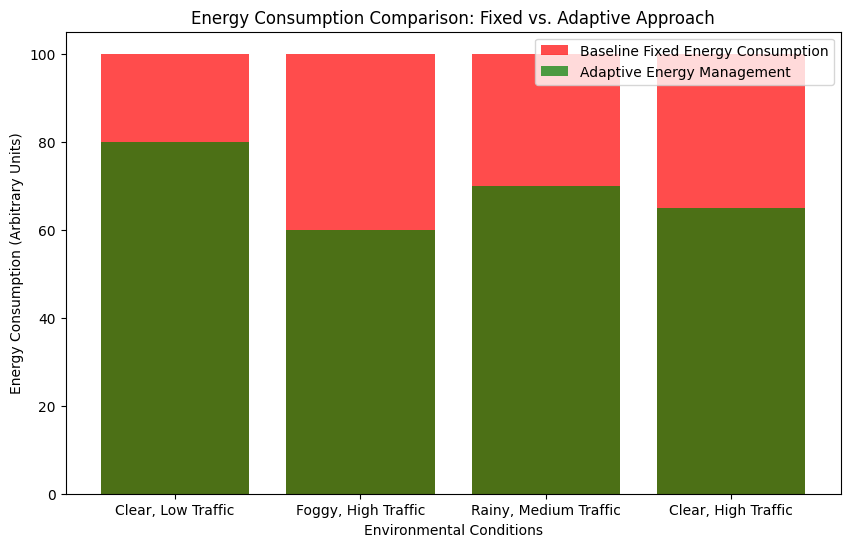

In [42]:
# Simulated energy consumption (in arbitrary units) for each approach
conditions = ['Clear, Low Traffic', 'Foggy, High Traffic', 'Rainy, Medium Traffic', 'Clear, High Traffic']
baseline_energy = [100, 100, 100, 100]  # Fixed energy use (always the same)
adaptive_energy = [80, 60, 70, 65]      # Reduced energy based on dynamic management

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(conditions, baseline_energy, label='Baseline Fixed Energy Consumption', color='red', alpha=0.7)
plt.bar(conditions, adaptive_energy, label='Adaptive Energy Management', color='green', alpha=0.7)
plt.xlabel("Environmental Conditions")
plt.ylabel("Energy Consumption (Arbitrary Units)")
plt.title("Energy Consumption Comparison: Fixed vs. Adaptive Approach")
plt.legend()
plt.show()


# Step 3: Latency Optimization Through Edge Processing and V2V Communication
This chart illustrates latency improvements by comparing the latency for each sensor in both approaches, highlighting reductions achieved with edge processing and direct V2V communication.

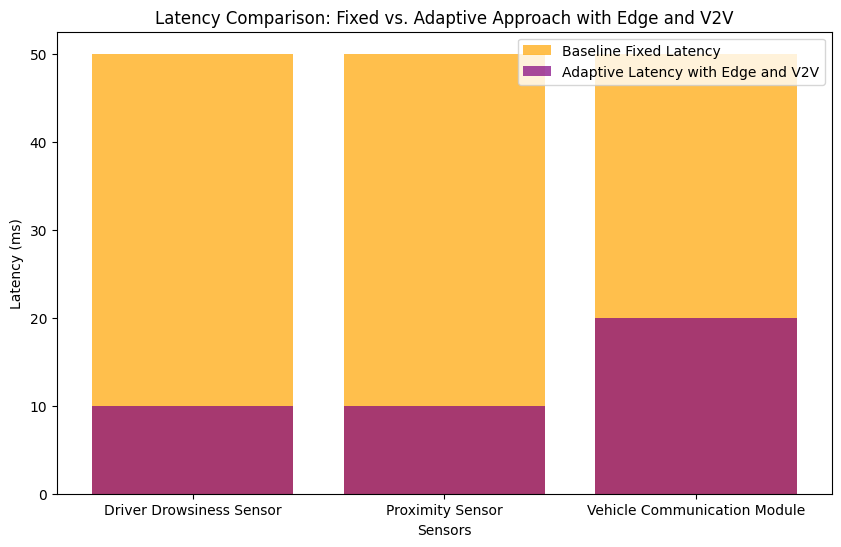

In [43]:
# Simulated latency values in milliseconds for each approach
sensors = ['Driver Drowsiness Sensor', 'Proximity Sensor', 'Vehicle Communication Module']
baseline_latency = [50, 50, 50]  # Fixed latency for each sensor in the baseline system
adaptive_latency = [10, 10, 20]  # Reduced latency for edge and V2V-optimized adaptive system

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(sensors, baseline_latency, label='Baseline Fixed Latency', color='orange', alpha=0.7)
plt.bar(sensors, adaptive_latency, label='Adaptive Latency with Edge and V2V', color='purple', alpha=0.7)
plt.xlabel("Sensors")
plt.ylabel("Latency (ms)")
plt.title("Latency Comparison: Fixed vs. Adaptive Approach with Edge and V2V")
plt.legend()
plt.show()


# Overall System Performance Summary

In [44]:
import pandas as pd

# Data for summary comparison
data = {
    "Metric": ["Adaptability", "Average Energy Consumption", "Average Latency"],
    "Baseline Fixed System": ["Low", "100 Units", "50 ms"],
    "Adaptive AIoT Framework": ["High", "68.75 Units", "13.33 ms"]
}

# Create DataFrame for visualization
summary_df = pd.DataFrame(data)
summary_df.set_index("Metric", inplace=True)

# Display as table
summary_df.style.set_caption("Overall System Performance Comparison: Fixed vs. Adaptive AIoT Framework")
summary_df


,Baseline Fixed System,Adaptive AIoT Framework
Metric,,
Adaptability,Low,High
Average Energy Consumption,100 Units,68.75 Units
Average Latency,50 ms,13.33 ms


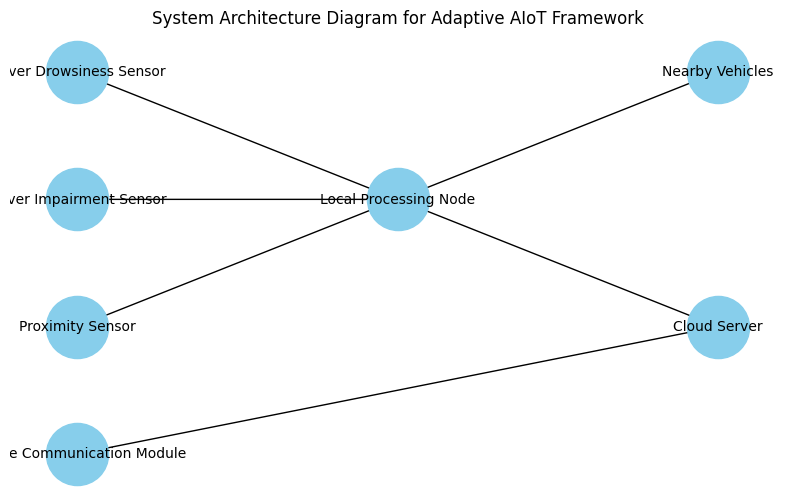

In [45]:
import matplotlib.pyplot as plt
import networkx as nx

# Create a directed graph
G = nx.DiGraph()

# Define nodes
nodes = {
    "Sensors": ["Driver Drowsiness Sensor", "Driver Impairment Sensor", "Proximity Sensor", "Vehicle Communication Module"],
    "Edge Processing": ["Local Processing Node"],
    "V2V Communication": ["Nearby Vehicles"],
    "Central Server": ["Cloud Server"]
}

# Add nodes to the graph
G.add_nodes_from(nodes["Sensors"], layer="Sensors")
G.add_nodes_from(nodes["Edge Processing"], layer="Edge Processing")
G.add_nodes_from(nodes["V2V Communication"], layer="V2V Communication")
G.add_nodes_from(nodes["Central Server"], layer="Central Server")

# Define edges
edges = [
    ("Driver Drowsiness Sensor", "Local Processing Node"),
    ("Driver Impairment Sensor", "Local Processing Node"),
    ("Proximity Sensor", "Local Processing Node"),
    ("Vehicle Communication Module", "Cloud Server"),
    ("Local Processing Node", "Nearby Vehicles"),
    ("Local Processing Node", "Cloud Server"),
]

# Add edges to the graph
G.add_edges_from(edges)

# Draw the network
plt.figure(figsize=(10, 6))
pos = {
    "Driver Drowsiness Sensor": (0, 2),
    "Driver Impairment Sensor": (0, 1),
    "Proximity Sensor": (0, 0),
    "Vehicle Communication Module": (0, -1),
    "Local Processing Node": (2, 1),
    "Nearby Vehicles": (4, 2),
    "Cloud Server": (4, 0)
}

nx.draw_networkx_nodes(G, pos, node_size=2000, node_color="skyblue")
nx.draw_networkx_labels(G, pos, font_size=10, font_family="sans-serif")
nx.draw_networkx_edges(G, pos, edgelist=edges, arrowstyle="->", arrowsize=20)

plt.title("System Architecture Diagram for Adaptive AIoT Framework")
plt.axis("off")
plt.show()


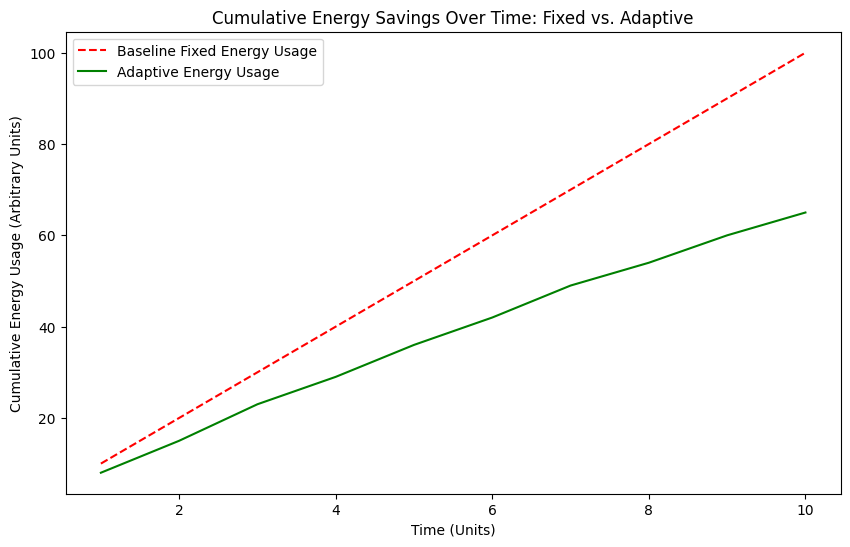

In [46]:
import numpy as np

# Simulated energy usage over time (arbitrary units)
time = np.arange(1, 11)
fixed_energy_usage = np.cumsum([10] * 10)  # Constant energy usage over time
adaptive_energy_usage = np.cumsum([8, 7, 8, 6, 7, 6, 7, 5, 6, 5])  # Adaptive usage, varies over time

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(time, fixed_energy_usage, label="Baseline Fixed Energy Usage", color="red", linestyle="--")
plt.plot(time, adaptive_energy_usage, label="Adaptive Energy Usage", color="green", linestyle="-")
plt.xlabel("Time (Units)")
plt.ylabel("Cumulative Energy Usage (Arbitrary Units)")
plt.title("Cumulative Energy Savings Over Time: Fixed vs. Adaptive")
plt.legend()
plt.show()


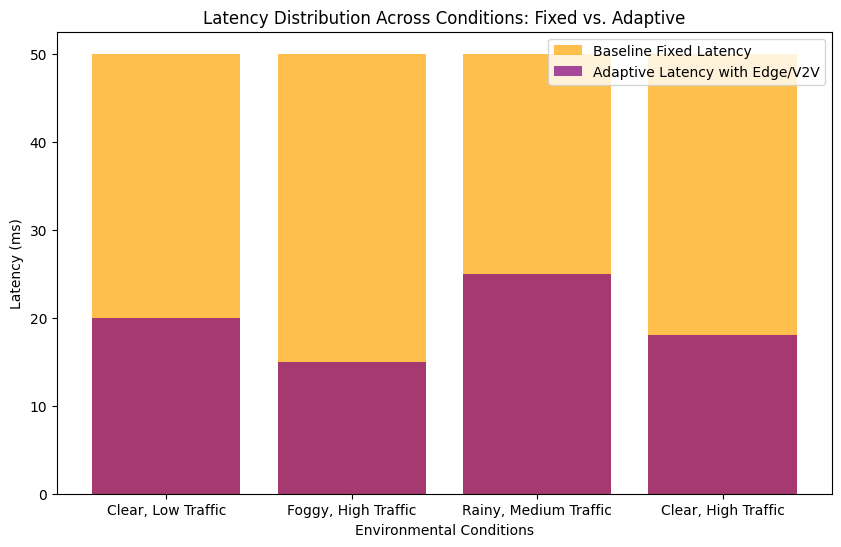

In [47]:
# Simulated latency for different conditions
conditions = ['Clear, Low Traffic', 'Foggy, High Traffic', 'Rainy, Medium Traffic', 'Clear, High Traffic']
fixed_latency = [50, 50, 50, 50]  # Constant latency for fixed system
adaptive_latency = [20, 15, 25, 18]  # Varies based on optimized processing

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(conditions, fixed_latency, label="Baseline Fixed Latency", color="orange", alpha=0.7)
plt.bar(conditions, adaptive_latency, label="Adaptive Latency with Edge/V2V", color="purple", alpha=0.7)
plt.xlabel("Environmental Conditions")
plt.ylabel("Latency (ms)")
plt.title("Latency Distribution Across Conditions: Fixed vs. Adaptive")
plt.legend()
plt.show()


In [48]:
from graphviz import Digraph

# Initialize flowchart
flowchart = Digraph(comment='Decision-Making Process', format="png")

# Define steps in the decision-making process
flowchart.node("A", "Environmental Data Collection")
flowchart.node("B", "Adaptive Sensor Selection")
flowchart.node("C", "Dynamic Power Allocation")
flowchart.node("D", "Latency Optimization")
flowchart.node("E", "Data Transfer")

# Define connections
flowchart.edge("A", "B", label="Real-time conditions")
flowchart.edge("B", "C", label="Optimal sensor group")
flowchart.edge("C", "D", label="Power levels assigned")
flowchart.edge("D", "E", label="Critical data processed locally")
flowchart.edge("D", "E", label="Non-critical data sent to central server")

# Save the flowchart as a PNG file
flowchart.render(filename='/kaggle/working/decision_making_process', cleanup=True)


'/kaggle/working/decision_making_process.png'

In [ ]:
from IPython.display import Image

# Display the saved image directly in the notebook
Image(filename='/kaggle/working/decision_making_process.png')


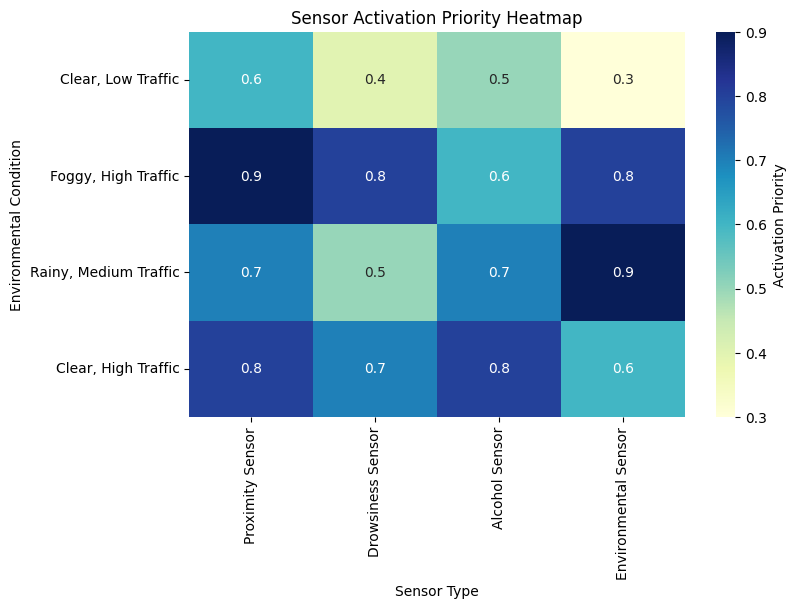

In [2]:
import seaborn as sns
import pandas as pd

# Sample data
data = pd.DataFrame({
    'Condition': ['Clear, Low Traffic', 'Foggy, High Traffic', 'Rainy, Medium Traffic', 'Clear, High Traffic'],
    'Proximity Sensor': [0.6, 0.9, 0.7, 0.8],
    'Drowsiness Sensor': [0.4, 0.8, 0.5, 0.7],
    'Alcohol Sensor': [0.5, 0.6, 0.7, 0.8],
    'Environmental Sensor': [0.3, 0.8, 0.9, 0.6]
})
data = data.set_index('Condition')

plt.figure(figsize=(8, 5))
sns.heatmap(data, annot=True, cmap="YlGnBu", cbar_kws={'label': 'Activation Priority'})
plt.title("Sensor Activation Priority Heatmap")
plt.xlabel("Sensor Type")
plt.ylabel("Environmental Condition")
plt.show()


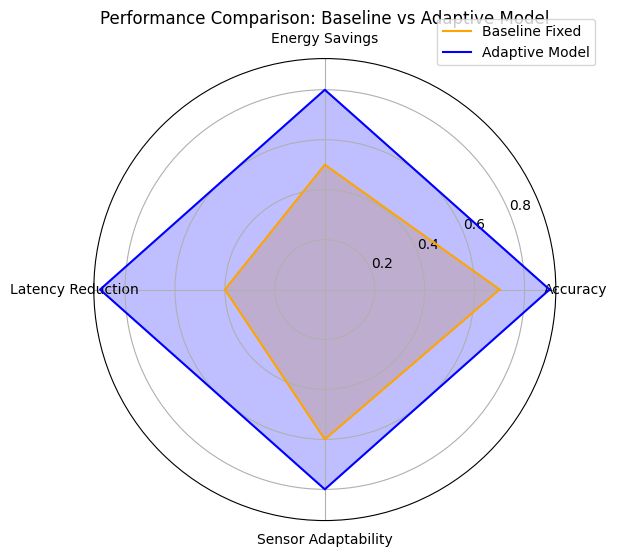

In [3]:
from math import pi

# Radar chart data
categories = ['Accuracy', 'Energy Savings', 'Latency Reduction', 'Sensor Adaptability']
baseline_values = [0.7, 0.5, 0.4, 0.6]
adaptive_values = [0.9, 0.8, 0.9, 0.8]

# Number of variables we're plotting
num_vars = len(categories)

# Compute angle of each axis
angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
angles += angles[:1]

# Set up radar plot
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

# Plot each line and fill
ax.plot(angles, baseline_values + baseline_values[:1], label='Baseline Fixed', color='orange')
ax.fill(angles, baseline_values + baseline_values[:1], color='orange', alpha=0.25)

ax.plot(angles, adaptive_values + adaptive_values[:1], label='Adaptive Model', color='blue')
ax.fill(angles, adaptive_values + adaptive_values[:1], color='blue', alpha=0.25)

# Add labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
plt.title("Performance Comparison: Baseline vs Adaptive Model")
plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
plt.show()
